In [55]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from adjustText import adjust_text
import pathlib as Path
%load_ext autoreload
%autoreload 2
sys.path.append(os.path.abspath(".."))
from src.get_visual import save_report_visual

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Set a professional visual style
sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('../data/processed/ipl_features_regular.csv')

# Do teams that win the toss actually win more matches?

Saved: toss_advantage_donut.png


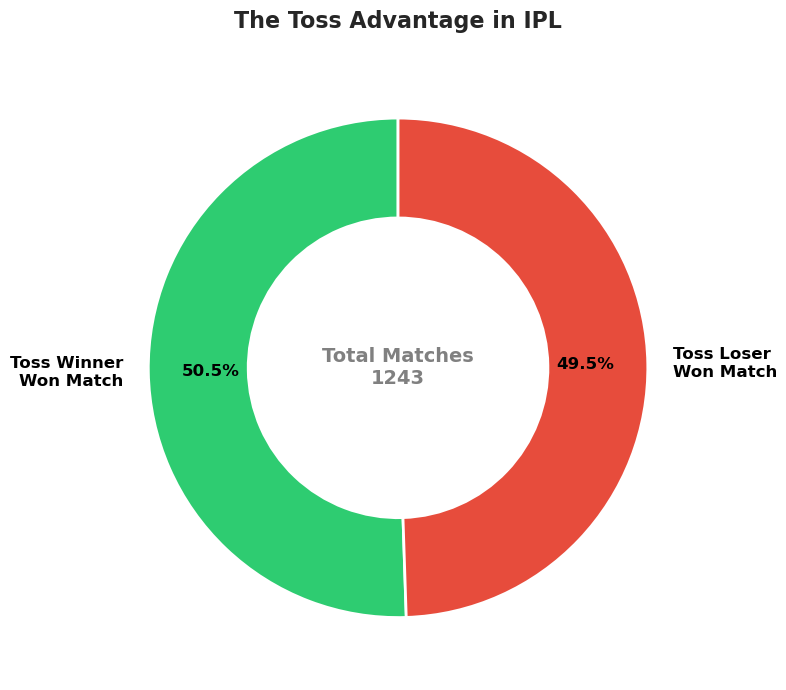

In [4]:
# --- STEP 1: Convert to Match-Level Data ---
# Drop duplicates so we only have exactly 1 row for every unique match_id
match_df = df.drop_duplicates(subset=['match_id']).copy()

# Create a simple True/False column if the toss winner also won the match
match_df['toss_winner_won_match'] = match_df['toss_winner'] == match_df['winner']
toss_counts = match_df['toss_winner_won_match'].value_counts()

# --- STEP 2: Build the Donut Chart ---
# We explicitly create 'fig' and 'ax' so we can pass 'fig' to our save function later
fig, ax = plt.subplots(figsize=(8, 8))

# Data setup
labels = ['Toss Winner\nWon Match', 'Toss Loser\nWon Match']
sizes = [toss_counts[True], toss_counts[False]]
colors = ['#2ecc71', '#e74c3c']

# Draw the pie chart with a 'wedgeprops' width to turn it into a donut
wedges, texts, autotexts = ax.pie(
    sizes, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',       # Formats the percentages automatically
    startangle=90,           # Starts the first slice at the top (12 o'clock)
    pctdistance=0.75,        # Pushes the percentage text slightly outward
    textprops=dict(color="black", fontsize=12, fontweight='bold'),
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2) # The donut hole magic!
)

# Add central text inside the donut hole
total_matches = len(match_df)
ax.text(0, 0, f"Total Matches\n{total_matches}", ha='center', va='center', fontsize=14, fontweight='bold', color='gray')

# Add a title
plt.title('The Toss Advantage in IPL', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()

# --- STEP 3: Save and Display ---
# Save to your visuals folder (it will create the file before plt.show() wipes the canvas)
save_report_visual(fig, 'toss_advantage_donut.png')

# Render it in the notebook
plt.show()

Saved: stadium_bias_diverging.png


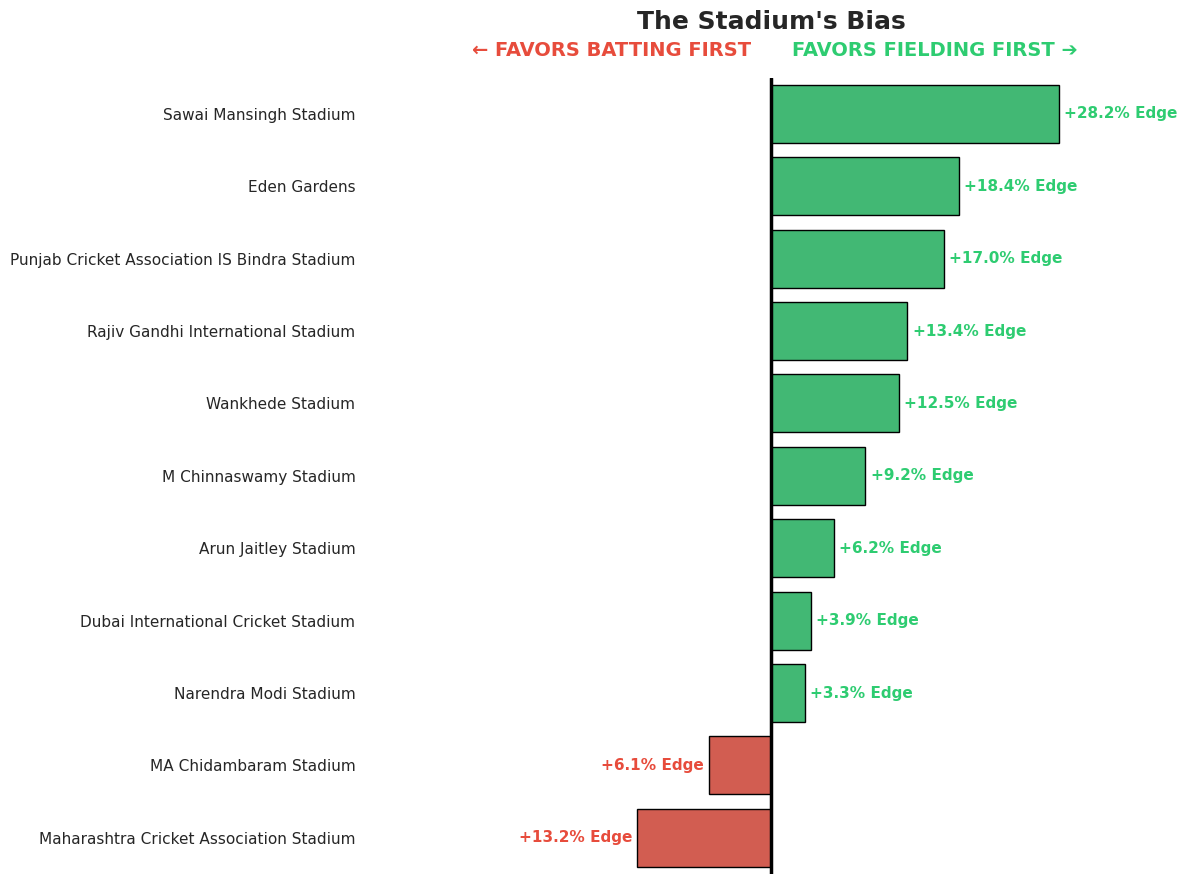

In [5]:
# --- STEP 1: Process and Filter for Established Stadiums ---
# Get match-level data
match_df = df.drop_duplicates(subset=['match_id']).copy()

# Keep only stadiums with at least 40 matches to ensure statistical relevance
venue_counts = match_df['venue'].value_counts()
top_venues = venue_counts[venue_counts >= 40].index
venue_toss_data = match_df[match_df['venue'].isin(top_venues)].copy()

# --- STEP 2: Calculate Toss Win Rates ---
# Track if the toss winner also won the match
venue_toss_data['toss_winner_won'] = (venue_toss_data['toss_winner'] == venue_toss_data['winner']).astype(int)

# Group by venue and decision to find the win percentages
venue_stats = venue_toss_data.groupby(['venue', 'toss_decision'])['toss_winner_won'].mean().reset_index()
venue_stats['win_percentage'] = venue_stats['toss_winner_won'] * 100

# Pivot data so 'bat' and 'field' are columns next to each venue
heatmap_data = venue_stats.pivot(index='venue', columns='toss_decision', values='win_percentage')

# --- STEP 3: Calculate the Diverging Chasing Advantage ---
bias_df = heatmap_data.copy().reset_index()
bias_df['chasing_advantage'] = bias_df['field'] - bias_df['bat']
bias_df = bias_df.sort_values('chasing_advantage', ascending=False)

# Map color palette: Green if chasing is better (>0), Red if batting first is better (<0)
color_map = {row['venue']: '#2ecc71' if row['chasing_advantage'] > 0 else '#e74c3c' for _, row in bias_df.iterrows()}

# --- STEP 4: Build the Diverging Visual ---
# Explicitly initialize fig and ax for saving
fig, ax = plt.subplots(figsize=(12, 9))

sns.barplot(
    data=bias_df,
    x='chasing_advantage',
    y='venue',
    hue='venue',            # Avoid modern Seaborn palette warnings
    palette=color_map,
    edgecolor='black',
    legend=False
)

# Draw a bold neutral baseline at 0%
plt.axvline(0, color='black', linewidth=2.5)

# --- STEP 5: UX Enhancements & Annotations ---
# Nuke the default X-axis tick labels and layout clutter
ax.set_xticks([])
plt.xlabel('')
plt.ylabel('')

# Add contextual Zone Headers at the top of the canvas
plt.text(2, -0.8, 'FAVORS FIELDING FIRST ➔', color='#2ecc71', fontsize=14, fontweight='bold', ha='left')
plt.text(-2, -0.8, '← FAVORS BATTING FIRST', color='#e74c3c', fontsize=14, fontweight='bold', ha='right')

# Dynamically place clear text values onto the bars based on direction
for p in ax.patches:
    value = p.get_width()
    if np.isnan(value): 
        continue
        
    # Right-facing bars (Chasing Advantage)
    if value > 0:
        ax.text(value + 0.5, p.get_y() + p.get_height()/2, f"+{value:.1f}% Edge", 
                va='center', ha='left', fontsize=11, fontweight='bold', color='#2ecc71')
    # Left-facing bars (Defending Advantage)
    elif value < 0:
        ax.text(value - 0.5, p.get_y() + p.get_height()/2, f"+{abs(value):.1f}% Edge", 
                va='center', ha='right', fontsize=11, fontweight='bold', color='#e74c3c')

# Set final title
plt.title("The Stadium's Bias", fontsize=18, fontweight='bold', pad=35)

# Expand the X-axis limit boundaries so labels never clip out of bounds
max_val = bias_df['chasing_advantage'].abs().max()
plt.xlim(-max_val * 1.4, max_val * 1.4)

# Nuke borders
sns.despine(bottom=True, left=True)
plt.tight_layout()

# --- STEP 6: Save and Show ---
# Save the plot before showing it wipes the memory canvas
save_report_visual(fig, 'stadium_bias_diverging.png')

plt.show()

Saved: decision_matrix_advanced.png


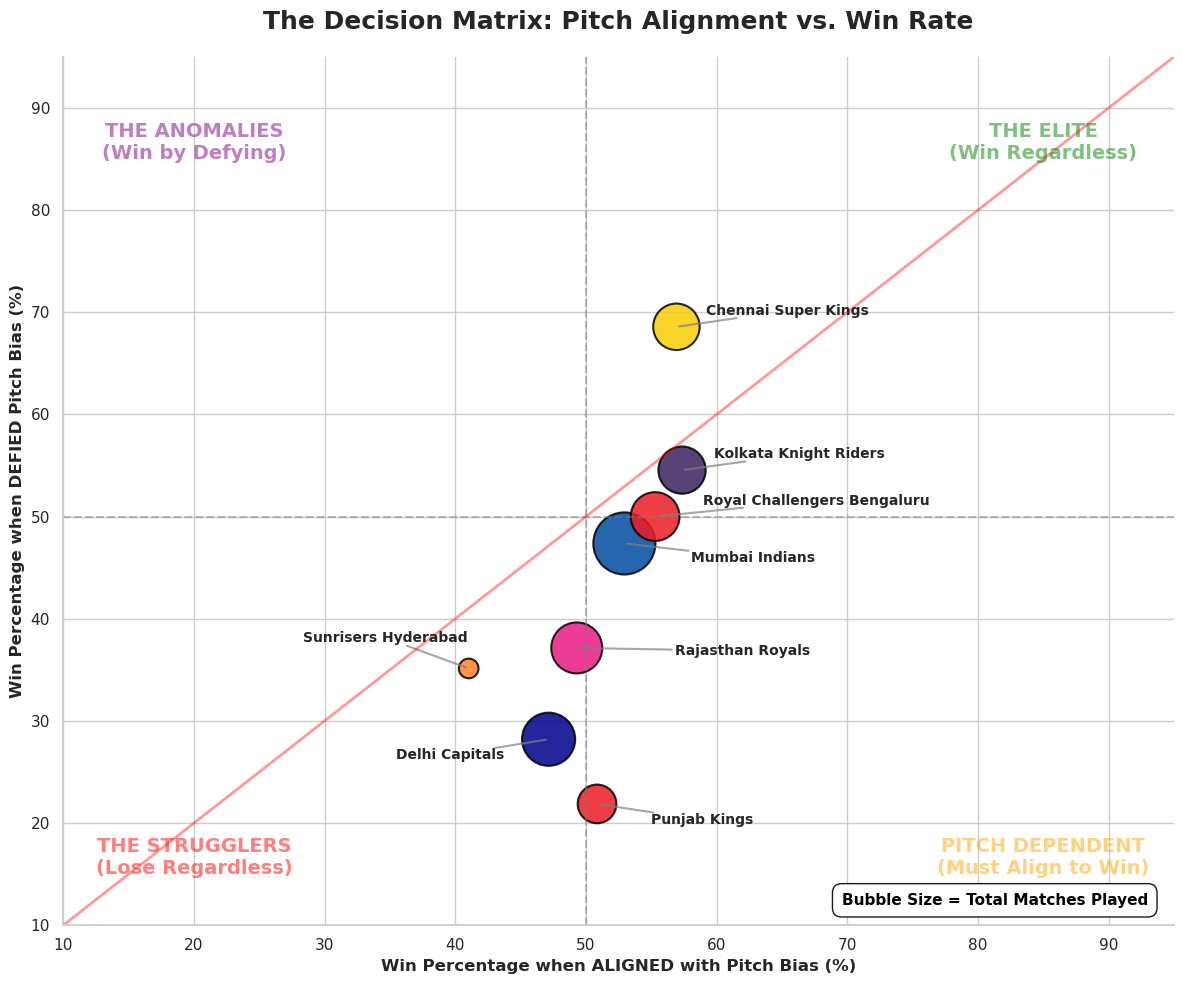

In [18]:
# --- PRE-REQUISITE: CALCULATE ALIGNMENT STATS ---
match_df = df.drop_duplicates(subset=['match_id']).copy()

venue_counts = match_df['venue'].value_counts()
top_venues = venue_counts[venue_counts >= 40].index
v_data = match_df[match_df['venue'].isin(top_venues)].copy()
v_data['toss_winner_won'] = (v_data['toss_winner'] == v_data['winner']).astype(int)

v_stats = v_data.groupby(['venue', 'toss_decision'])['toss_winner_won'].mean().unstack()
v_stats['chasing_bias'] = v_stats['field'] - v_stats['bat']

match_df['venue_bias'] = match_df['venue'].map(v_stats['chasing_bias'])

def determine_strategy(row):
    if pd.isna(row['venue_bias']):
        return 'Unknown'
    optimal_decision = 'field' if row['venue_bias'] > 0 else 'bat'
    return 'Aligned with Pitch Bias' if row['toss_decision'] == optimal_decision else 'Defied Pitch Bias'

match_df['Strategy'] = match_df.apply(determine_strategy, axis=1)

strategy_df = match_df[match_df['Strategy'] != 'Unknown'].copy()
strategy_df['toss_winner_won'] = (strategy_df['toss_winner'] == strategy_df['winner']).astype(int)


# --- UPGRADE 1: Calculate Total Matches for Bubble Size ---
# Get the total volume of matches each team played in this dataset
team_volumes = strategy_df['toss_winner'].value_counts().reset_index()
team_volumes.columns = ['toss_winner', 'Total_Matches']

# Calculate win percentages
alignment_stats = strategy_df.groupby(['toss_winner', 'Strategy'])['toss_winner_won'].mean().reset_index()
alignment_stats['win_percentage'] = alignment_stats['toss_winner_won'] * 100


# --- STEP 1: Pivot the Data ---
matrix_df = alignment_stats.pivot(
    index='toss_winner', 
    columns='Strategy', 
    values='win_percentage'
).reset_index()

matrix_df.columns.name = None
matrix_df = matrix_df.rename(columns={
    'Aligned with Pitch Bias': 'Aligned_Win',
    'Defied Pitch Bias': 'Defied_Win'
})
matrix_df = matrix_df.dropna()

# Merge the Total_Matches back into our plotting matrix
matrix_df = matrix_df.merge(team_volumes, on='toss_winner', how='left')
# Drop any team that hasn't made at least 40 toss decisions in the dataset
matrix_df = matrix_df[matrix_df['Total_Matches'] >= 30].copy()

# --- UPGRADE 2: Define Official IPL Franchise Colors ---
team_colors = {
    'Chennai Super Kings': '#F9CD05',       # CSK Yellow
    'Mumbai Indians': '#004BA0',            # MI Blue
    'Royal Challengers Bengaluru': '#EC1C24', # RCB Red
    'Kolkata Knight Riders': '#3A225D',     # KKR Purple
    'Delhi Capitals': '#00008B',            # DC Dark Blue
    'Rajasthan Royals': '#EA1A85',          # RR Pink
    'Sunrisers Hyderabad': '#FF822A',       # SRH Orange
    'Punjab Kings': '#ED1B24',              # PBKS Red
    'Lucknow Super Giants': '#00B3DF',      # LSG Cyan
    'Gujarat Titans': '#1B2133',            # GT Navy
    # Historical teams just in case they exist in your dataset
    'Deccan Chargers': '#000080',
    'Pune Warriors': '#2F9BE3',
    'Gujarat Lions': '#FF822A',
    'Rising Pune Supergiant': '#D11D9B'
}


# --- STEP 2: Build the Advanced Scatter Plot Matrix ---
fig, ax = plt.subplots(figsize=(12, 10))

sns.scatterplot(
    data=matrix_df,
    x='Aligned_Win',
    y='Defied_Win',
    size='Total_Matches',      # ⬅ Maps bubble size to match volume
    sizes=(200, 2000),         # ⬅ Min and max bubble scale 
    hue='toss_winner',         # ⬅ Maps colors to the team names
    palette=team_colors,       # ⬅ Applies our custom hex dictionary
    edgecolor='black',
    linewidth=1.5,
    alpha=0.85,
    legend=False,              # ⬅ Turns off the legend so it doesn't clutter the chart
    ax=ax
)


# --- STEP 3: Draw the Analytical Lines ---
plt.axvline(50, color='gray', linestyle='--', alpha=0.5)
plt.axhline(50, color='gray', linestyle='--', alpha=0.5)
plt.plot([0, 100], [0, 100], color='red', linestyle='-', alpha=0.4, linewidth=2)


# --- STEP 4: Annotate the Teams and Quadrants ---
texts = [] # Create an empty list to hold our text objects

for i, row in matrix_df.iterrows():
    # We append the text directly to exactly where the dot is (no manual nudging needed!)
    texts.append(
        plt.text(
            row['Aligned_Win'],    
            row['Defied_Win'],    
            row['toss_winner'], 
            fontsize=10, 
            fontweight='bold',
            ha='center'               
        )
    )

# Now, we let adjust_text calculate the math to push them apart
adjust_text(
    texts, 
    arrowprops=dict(arrowstyle="-", color='gray', lw=1.5, alpha=0.7), # Draws neat lines if text gets pushed far
    expand=(1.5, 1.5) # Gives a little extra breathing room between labels
)

plt.text(85, 85, 'THE ELITE\n(Win Regardless)', color='green', fontsize=14, fontweight='bold', alpha=0.5, ha='center')
plt.text(85, 15, 'PITCH DEPENDENT\n(Must Align to Win)', color='orange', fontsize=14, fontweight='bold', alpha=0.5, ha='center')
plt.text(20, 15, 'THE STRUGGLERS\n(Lose Regardless)', color='red', fontsize=14, fontweight='bold', alpha=0.5, ha='center')
plt.text(20, 85, 'THE ANOMALIES\n(Win by Defying)', color='purple', fontsize=14, fontweight='bold', alpha=0.5, ha='center')


# --- STEP 5: Final Beautification & Simple Size Key ---
plt.title('The Decision Matrix: Pitch Alignment vs. Win Rate', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Win Percentage when ALIGNED with Pitch Bias (%)', fontsize=12, fontweight='bold')
plt.ylabel('Win Percentage when DEFIED Pitch Bias (%)', fontsize=12, fontweight='bold')

# The simple, elegant text box
plt.text(
    93, 12, # Placed in the bottom right corner based on our X/Y limits
    "Bubble Size = Total Matches Played", 
    fontsize=11, 
    fontweight='bold',
    color='black',
    ha='right', # Aligns the box to the right side of our coordinate
    bbox=dict(
        facecolor='white', 
        edgecolor='black', 
        boxstyle='round,pad=0.6', # Gives the box nice rounded corners
        alpha=0.9
    )
)

plt.xlim(10, 95)
plt.ylim(10, 95)

sns.despine()
plt.tight_layout()

plt.xlim(10, 95)
plt.ylim(10, 95)

sns.despine()
plt.tight_layout()

# --- STEP 6: Export and Display ---
save_report_visual(fig, 'decision_matrix_advanced.png')
plt.show()

# Which phase impacts victory the most : Powerplay, Middle Overs or Death Overs?

Saved: phase_averages_bar.png


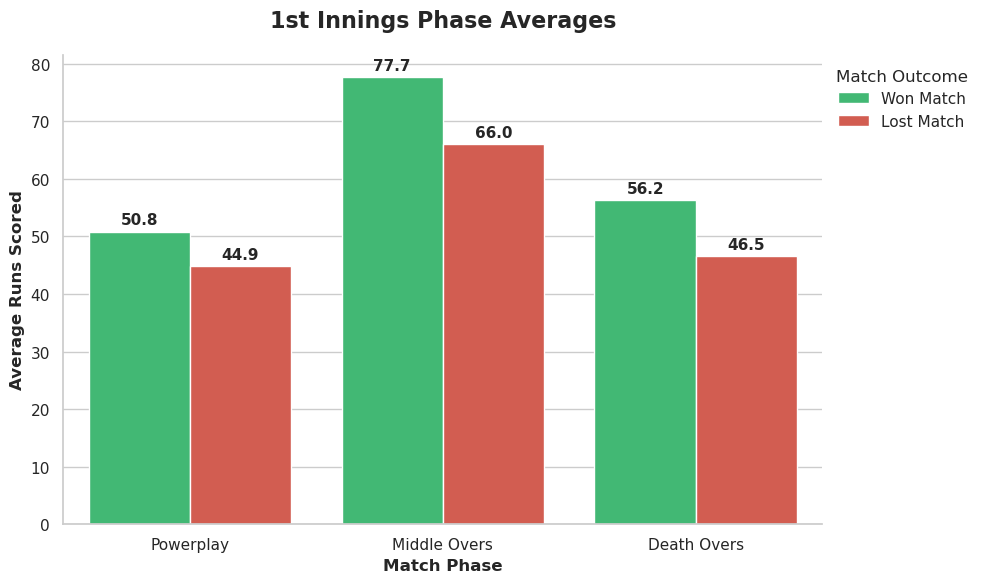

In [56]:
# --- STEP 1: Isolate 1st Innings & Determine Outcome ---
# Keep only 1st innings and filter out rain-reduced matches
first_innings = df[(df['innings'] == 1) & (df['is_rain_reduced'] == 0)].copy()

# Create a clear flag: Did the team setting the target actually win the game?
first_innings['outcome'] = np.where(
    first_innings['batting_team'] == first_innings['winner'], 
    'Won Match', 
    'Lost Match'
)

# --- STEP 2: Calculate Runs per Phase for Every Match ---
# Group by match, phase, and outcome to sum the runs
phase_totals = first_innings.groupby(
    ['match_id', 'phase', 'outcome']
)['runs_total'].sum().reset_index()


# --- STEP 3: Build the Grouped Bar Chart ---
# Explicitly initialize fig and ax for saving
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=phase_totals,
    x='phase',
    y='runs_total',
    hue='outcome',
    order=['Powerplay', 'Middle Overs', 'Death Overs'], 
    palette={'Won Match': '#2ecc71', 'Lost Match': '#e74c3c'}, # Safer dictionary mapping
    errorbar=None, 
    ax=ax
)

# Add titles and labels
plt.title('1st Innings Phase Averages', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Match Phase', fontsize=12, fontweight='bold')
plt.ylabel('Average Runs Scored', fontsize=12, fontweight='bold')

# Add the exact numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=11, fontweight='bold')

# Move the legend cleanly out of the way
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title='Match Outcome', frameon=False)

# Clean up the borders
sns.despine()
plt.tight_layout()

# --- STEP 4: Save and Display ---
save_report_visual(fig, 'phase_averages_bar.png')
plt.show()

Saved: strike_rate_phase_impact_curve.png


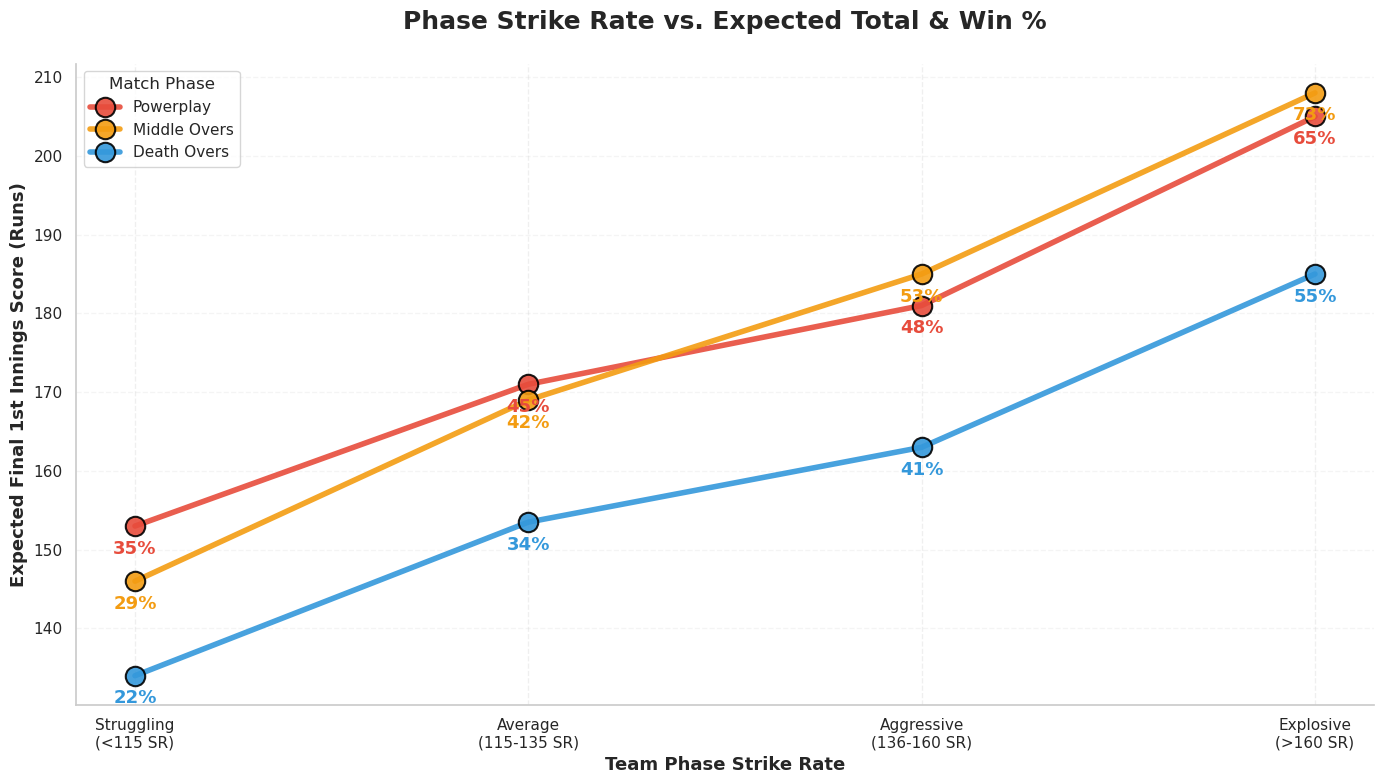

In [68]:
# --- STEP 1: Isolate 1st Innings ---
inn1_df = df[(df['innings'] == 1) & (df['is_rain_reduced']==0)].copy()

# --- STEP 2: Calculate Strike Rate per Match AND Phase ---
valid_balls_df = inn1_df[inn1_df['extras_wides'].isna() | (inn1_df['extras_wides'] == 0)]

phase_stats = valid_balls_df.groupby(['match_id', 'phase']).agg(
    phase_runs=('runs_batter', 'sum'),
    phase_balls=('ball', 'count')
).reset_index()

phase_stats['strike_rate'] = (phase_stats['phase_runs'] / phase_stats['phase_balls']) * 100

# --- STEP 3: Create Universal 'Strike Rate Buckets' ---
bins = [-1, 115, 135, 160, 1000]
labels = ['Struggling\n(<115 SR)', 'Average\n(115-135 SR)', 'Aggressive\n(136-160 SR)', 'Explosive\n(>160 SR)']
phase_stats['sr_bucket'] = pd.cut(phase_stats['strike_rate'], bins=bins, labels=labels)

# --- STEP 4: Get Final Scores and Match Outcomes ---
final_scores = inn1_df.groupby('match_id')['current_score'].max().reset_index(name='final_total')

match_outcomes = inn1_df.groupby('match_id').apply(
    lambda x: 1 if x['batting_team'].iloc[0] == x['winner'].iloc[0] else 0
).reset_index(name='bat_first_won')

sr_df = pd.merge(phase_stats, final_scores, on='match_id')
sr_df = pd.merge(sr_df, match_outcomes, on='match_id')

# --- STEP 5: Aggregate the Dual Metrics ---
# Added observed=False to prevent Pandas FutureWarnings with categorical groupings
curve_df = sr_df.groupby(['phase', 'sr_bucket'], observed=False).agg(
    expected_score=('final_total', 'median'),
    win_rate=('bat_first_won', 'mean')
).reset_index()

curve_df['win_percentage'] = curve_df['win_rate'] * 100
curve_df = curve_df.dropna()


# --- STEP 6: Build the 3-Line Visual ---
# Explicitly initialize fig and ax for saving
fig, ax = plt.subplots(figsize=(14, 8))

phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}

# Draw the lines for Expected Score (Physical Runs)
sns.lineplot(
    data=curve_df,
    x='sr_bucket',
    y='expected_score',
    hue='phase',
    hue_order=phase_order,
    palette=phase_colors,
    linewidth=4,
    marker='o',
    markersize=14,
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9,
    ax=ax
)

# Add the Win Percentage Annotations
for i, row in curve_df.iterrows():
    text_color = phase_colors[row['phase']]
    
    # Dynamic offset so text doesn't overlap if the dots get close
    #y_offset = 3 if row['phase'] != 'Middle Overs' else -4
    
    ax.text(
        row['sr_bucket'], 
        row['expected_score'] -3.5, 
        f"{int(row['win_percentage'])}%", 
        color=text_color, 
        ha='center', 
        fontsize=13, 
        fontweight='bold'
    )


# --- STEP 7: Professional Formatting ---
plt.title('Phase Strike Rate vs. Expected Total & Win %', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Team Phase Strike Rate', fontsize=13, fontweight='bold')
plt.ylabel('Expected Final 1st Innings Score (Runs)', fontsize=13, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.2)

ax.legend(title='Match Phase', loc='upper left', fontsize=11, title_fontsize=12)
sns.despine()

plt.tight_layout()

# --- STEP 8: Export and Display ---
save_report_visual(fig, 'strike_rate_phase_impact_curve.png')
plt.show()

Saved: wickets_lost_phase_impact.png


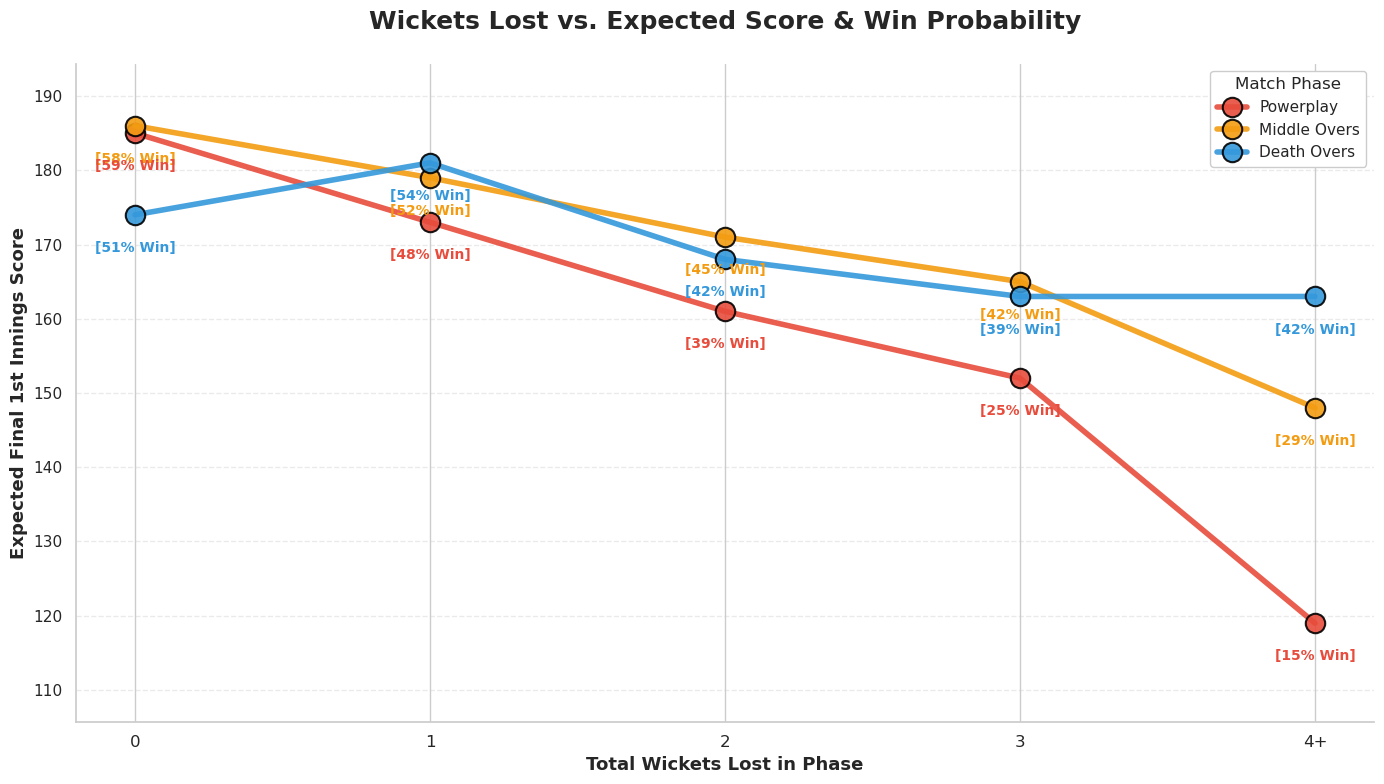

In [ ]:
# --- STEP 1: Add Win/Loss Data to the Match Summaries ---
inn1_df = df[(df['innings'] == 1) & (df['is_rain_reduced']==0)].copy()

phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}

# Create a flag for whether the team batting first actually won the match
inn1_df['bat_first_won'] = (inn1_df['batting_team'] == inn1_df['winner']).astype(int)

# Get final score AND win status for every match
match_summaries = inn1_df.groupby('match_id').agg(
    final_total=('current_score', 'max'),
    bat_first_won=('bat_first_won', 'max') # Status is the same for the whole match
).reset_index()

# Get wickets lost per phase
phase_wickets = inn1_df.groupby(['match_id', 'phase'])['is_wicket'].sum().unstack(fill_value=0).reset_index()
master_df = pd.merge(match_summaries, phase_wickets, on='match_id')

# --- STEP 2: Melt and Cap Wickets ---
melted_df = master_df.melt(
    id_vars=['match_id', 'final_total', 'bat_first_won'], 
    value_vars=['Powerplay', 'Middle Overs', 'Death Overs'], 
    var_name='Phase', 
    value_name='Wickets_Lost'
)
# Cap wickets at 4 to group extreme collapses together
melted_df['Wickets_Lost'] = melted_df['Wickets_Lost'].apply(lambda x: 4 if x >= 4 else x)

# --- STEP 3: Calculate Both Medians and Win Rates ---
curve_df = melted_df.groupby(['Phase', 'Wickets_Lost']).agg(
    expected_score=('final_total', 'median'),
    win_rate=('bat_first_won', 'mean')
).reset_index()

# Convert win rate to a readable percentage
curve_df['win_percentage'] = curve_df['win_rate'] * 100


# --- STEP 4: Build the Visual ---
# Explicitly initialize fig and ax for saving
fig, ax = plt.subplots(figsize=(14, 8))

# Draw the core trajectory lines
sns.lineplot(
    data=curve_df,
    x='Wickets_Lost',
    y='expected_score',
    hue='Phase',
    hue_order=phase_order,
    palette=phase_colors,
    linewidth=4,           
    marker='o',            
    markersize=14,         
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9,
    ax=ax
)

# --- STEP 5: The Annotation Masterstroke ---
for i, row in curve_df.iterrows():
    text_color = phase_colors[row['Phase']]
    
    # Print the Win Probability BELOW the dot
    ax.text(
        row['Wickets_Lost'], 
        row['expected_score'] - 5, # Nudge DOWN
        f"[{row['win_percentage']:.0f}% Win]", 
        color=text_color, 
        ha='center', 
        fontsize=10, 
        fontweight='bold'
    )

# --- STEP 6: Professional Formatting ---
plt.title('Wickets Lost vs. Expected Score & Win Probability', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Total Wickets Lost in Phase', fontsize=13, fontweight='bold')
plt.ylabel('Expected Final 1st Innings Score', fontsize=13, fontweight='bold')

plt.xticks(ticks=[0, 1, 2, 3, 4], labels=['0', '1', '2', '3', '4+'], fontsize=12)

# Expand the Y-axis slightly so our text annotations don't get cut off at the bottom
current_ylim = ax.get_ylim()
ax.set_ylim(current_ylim[0] - 10, current_ylim[1] + 5)

ax.legend(title='Match Phase', loc='upper right', fontsize=11, title_fontsize=12, framealpha=1)
plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()

# --- STEP 7: Export and Display ---
save_report_visual(fig, 'wickets_lost_phase_impact_curve.png')
plt.show()

Saved: dot_ball_2nd_innings_phase_chokehold.png


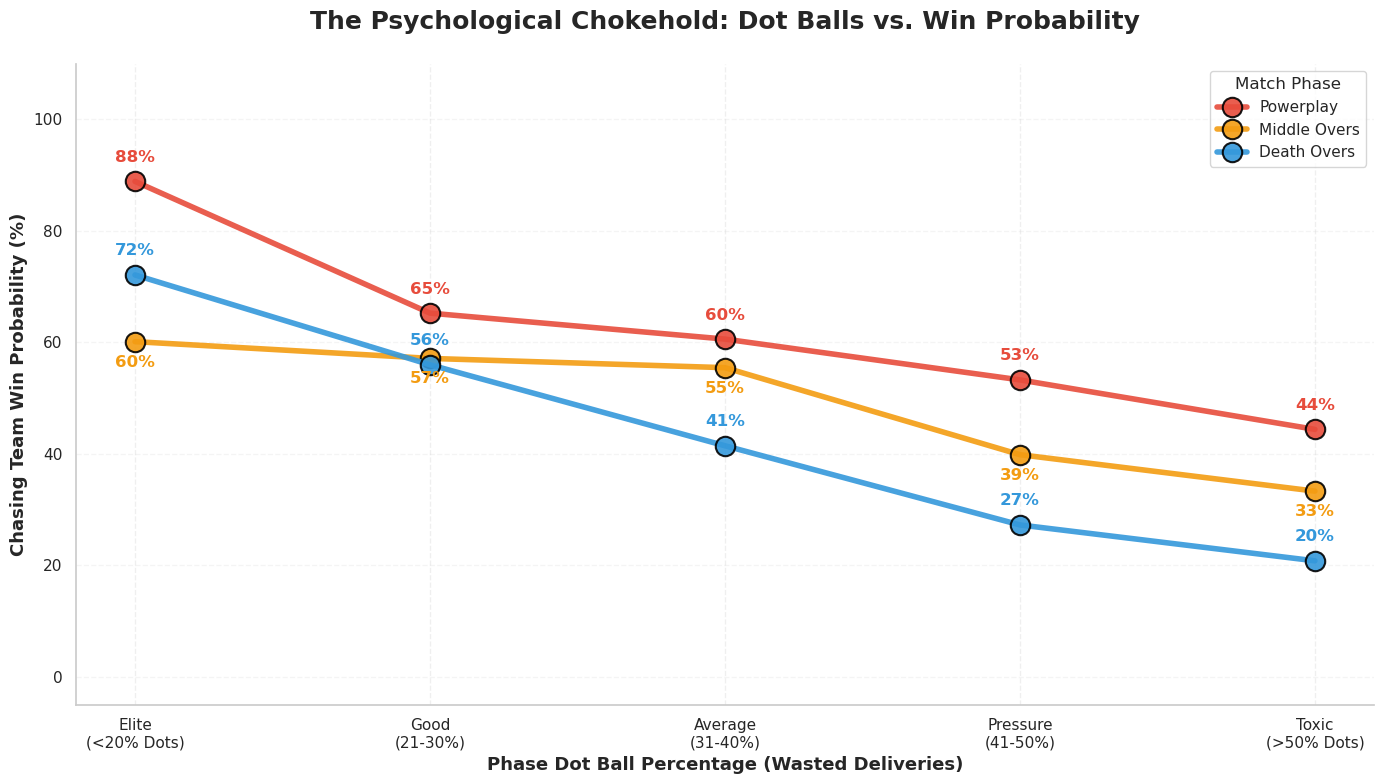

In [ ]:
# --- STEP 1: Isolate Run Chases (2nd Innings) ---
inn2_df = df[(df['innings'] == 2) & (df['is_rain_reduced']==0)].copy()

# Define a dot ball (Assuming 'runs_total' being 0 captures no runs scored)
inn2_df['is_dot'] = (inn2_df['runs_total'] == 0).astype(int)

# --- STEP 2: Calculate Dot Percentage ---
phase_stats = inn2_df.groupby(['match_id', 'phase']).agg(
    dot_balls=('is_dot', 'sum'),
    total_balls=('ball', 'count')
).reset_index()

phase_stats['dot_percentage'] = (phase_stats['dot_balls'] / phase_stats['total_balls']) * 100

# --- STEP 3: Create the 'Pressure Buckets' ---
bins = [-1, 20, 30, 40, 50, 101]
labels = ['Elite\n(<20% Dots)', 'Good\n(21-30%)', 'Average\n(31-40%)', 'Pressure\n(41-50%)', 'Toxic\n(>50% Dots)']
phase_stats['pressure_level'] = pd.cut(phase_stats['dot_percentage'], bins=bins, labels=labels)

# --- STEP 4: Map Outcomes ---
# Did the chasing team win the match?
match_outcomes = inn2_df.groupby('match_id').apply(
    lambda x: 1 if x['batting_team'].iloc[0] == x['winner'].iloc[0] else 0
).reset_index(name='chasing_team_won')

# Merge stats and outcomes
toxicity_df = pd.merge(phase_stats, match_outcomes, on='match_id')

# Aggregate the win percentage for each bucket
# Added observed=False to prevent Pandas FutureWarnings
curve_df = toxicity_df.groupby(['phase', 'pressure_level'], observed=False).agg(
    win_rate=('chasing_team_won', 'mean')
).reset_index()

curve_df['win_percentage'] = curve_df['win_rate'] * 100
curve_df = curve_df.dropna()


# --- STEP 5: Build the Visual ---
fig, ax = plt.subplots(figsize=(14, 8))

phase_order = ['Powerplay', 'Middle Overs', 'Death Overs']
phase_colors = {'Powerplay': '#e74c3c', 'Middle Overs': '#f39c12', 'Death Overs': '#3498db'}

# Draw the pressure trajectory lines using WIN PERCENTAGE as the Y-Axis
sns.lineplot(
    data=curve_df,
    x='pressure_level',
    y='win_percentage', # Corrected Y-Axis
    hue='phase',
    hue_order=phase_order,
    palette=phase_colors,
    linewidth=4,
    marker='o',
    markersize=14,
    markeredgecolor='black',
    markeredgewidth=1.5,
    alpha=0.9,
    ax=ax
)

# --- STEP 6: Annotations ---
for i, row in curve_df.iterrows():
    text_color = phase_colors[row['phase']]
    
    # Dynamic offset (now scaled for percentages, 0-100)
    y_offset = 3.5 if row['phase'] != 'Middle Overs' else -4.5
    
    ax.text(
        row['pressure_level'], 
        row['win_percentage'] + y_offset, 
        f"{int(row['win_percentage'])}%", 
        color=text_color, 
        ha='center', 
        fontsize=12, 
        fontweight='bold'
    )

# --- STEP 7: Professional Formatting ---
plt.title('The Psychological Chokehold: Dot Balls vs. Win Probability', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Phase Dot Ball Percentage (Wasted Deliveries)', fontsize=13, fontweight='bold')
plt.ylabel('Chasing Team Win Probability (%)', fontsize=13, fontweight='bold') # Corrected Label

# Set a strict 0-105% limit so the scale makes sense and text isn't cut off
ax.set_ylim(-5, 110)

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.grid(axis='y', linestyle='--', alpha=0.2)

ax.legend(title='Match Phase', loc='upper right', fontsize=11, title_fontsize=12)
sns.despine()

plt.tight_layout()

# --- STEP 8: Export and Display ---
save_report_visual(fig, 'dot_ball_2nd_innings_phase_chokehold_curve.png')
plt.show()

# Who are the top 5 batters and top 5 bowlers across 5 seasons?

Saved: top_5_batters_(2022-2026).png


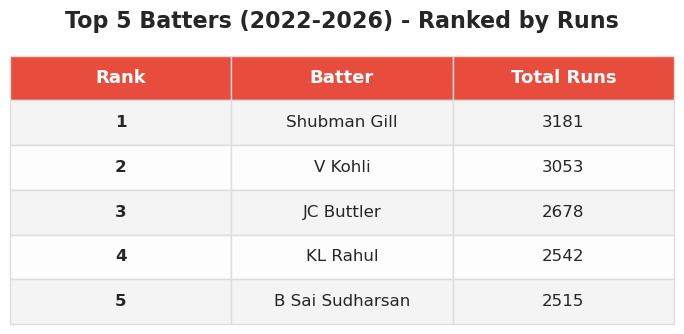

Saved: top_5_bowlers_(2022-2026).png


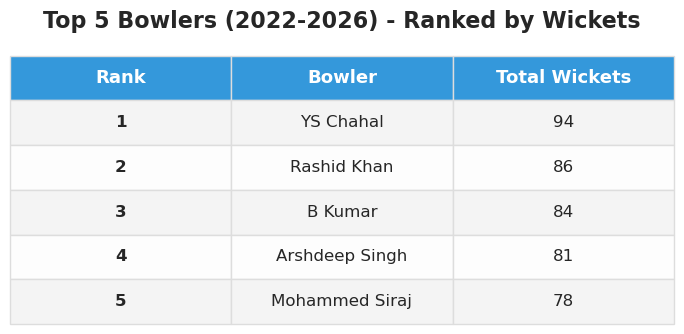

In [25]:
# --- STEP 1: Filter for the Modern Era (2022-2026) ---
target_seasons = ['2022', '2023', '2024', '2025', '2026', 2022, 2023, 2024, 2025, 2026]
modern_df = df[df['season'].isin(target_seasons)].copy()

# ==========================================
# --- STEP 2: TOP 5 BATTERS (PURELY BY RUNS)
# ==========================================
batters_runs = modern_df.groupby('batter')['runs_batter'].sum().reset_index(name='Total_Runs')
top_5_batters_runs = batters_runs.sort_values(by='Total_Runs', ascending=False).head(5)
top_5_batters_runs = top_5_batters_runs.rename(columns={'batter': 'Batter', 'Total_Runs': 'Total Runs'}).reset_index(drop=True)

# Add a Rank column for aesthetics
top_5_batters_runs.insert(0, 'Rank', range(1, 6))

# ==========================================
# --- STEP 3: TOP 5 BOWLERS (PURELY BY WICKETS)
# ==========================================
valid_dismissals = ['caught', 'bowled', 'lbw', 'caught and bowled', 'stumped', 'hit wicket']
wicket_df = modern_df[modern_df['wicket_kind'].isin(valid_dismissals)]
bowlers_wickets = wicket_df.groupby('bowler').size().reset_index(name='Total_Wickets')
top_5_bowlers_wickets = bowlers_wickets.sort_values(by='Total_Wickets', ascending=False).head(5)
top_5_bowlers_wickets = top_5_bowlers_wickets.rename(columns={'bowler': 'Bowler', 'Total_Wickets': 'Total Wickets'}).reset_index(drop=True)

# Add a Rank column for aesthetics
top_5_bowlers_wickets.insert(0, 'Rank', range(1, 6))

# ==========================================
# --- STEP 4: FUNCTION TO DRAW IMAGE TABLES ---
# ==========================================
def render_image_table(data, title, header_color, filename):
    fig, ax = plt.subplots(figsize=(7, 3.5)) # Size of the image
    ax.axis('off')
    
    # Draw the table
    table = ax.table(
        cellText=data.values, 
        colLabels=data.columns, 
        cellLoc='center', 
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1, 2)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd') # Light gray borders
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=13)
        else:
            # Alternating row colors for readability
            cell.set_facecolor('#fdfdfd' if row % 2 == 0 else '#f4f4f4')
            if col == 0: # Make the Rank column bold
                cell.set_text_props(weight='bold')
                
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Save the visual using our custom tool before showing
    save_report_visual(fig, filename)
    plt.show()

# --- STEP 5: GENERATE THE IMAGES ---
# Batting Table (Red Theme)
render_image_table(
    top_5_batters_runs, 
    "Top 5 Batters (2022-2026) - Ranked by Runs", 
    '#e74c3c',
    'top_5_batters_(2022-2026).png'
)

# Bowling Table (Blue Theme)
render_image_table(
    top_5_bowlers_wickets, 
    "Top 5 Bowlers (2022-2026) - Ranked by Wickets", 
    '#3498db',
    'top_5_bowlers_(2022-2026).png'
)

Saved: true_impact_batters_leaderboard.png


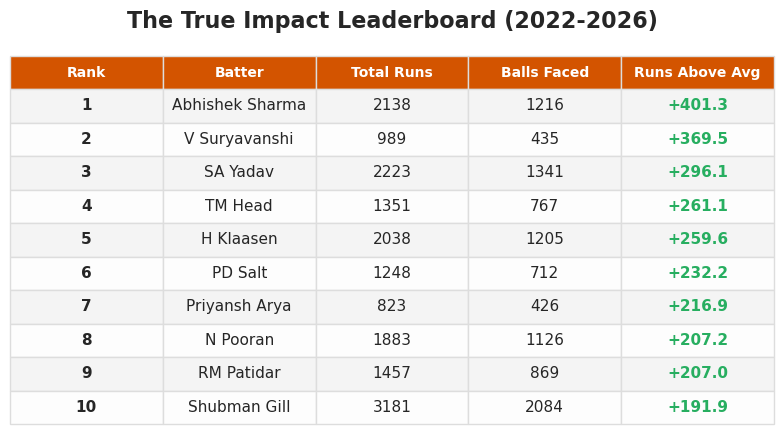

In [26]:
# --- STEP 1: Filter for the Modern Era & Standard Matches ---
target_seasons = ['2022', '2023', '2024', '2025', '2026', 2022, 2023, 2024, 2025, 2026]

# ---> THE FIX: Added is_rain_reduced == 0 <---
modern_df = df[(df['season'].isin(target_seasons)) & (df['is_rain_reduced'] == 0)].copy()

# Filter out wides to only count legitimate balls faced
valid_balls = modern_df[modern_df['extras_wides'].isna() | (modern_df['extras_wides'] == 0)].copy()

# --- STEP 2: Calculate the League Environment (Baseline) ---
phase_environment = valid_balls.groupby('phase').agg(
    total_league_runs=('runs_batter', 'sum'),
    total_league_balls=('ball', 'count')
).reset_index()

phase_environment['league_avg_rpb'] = phase_environment['total_league_runs'] / phase_environment['total_league_balls']

# --- STEP 3: Calculate Individual Player Stats per Phase ---
player_phase_stats = valid_balls.groupby(['batter', 'phase']).agg(
    actual_runs=('runs_batter', 'sum'),
    balls_faced=('ball', 'count')
).reset_index()

impact_df = pd.merge(player_phase_stats, phase_environment[['phase', 'league_avg_rpb']], on='phase', how='left')

# --- STEP 4: The True Impact Math ---
impact_df['expected_runs'] = impact_df['balls_faced'] * impact_df['league_avg_rpb']
impact_df['true_impact_raa'] = impact_df['actual_runs'] - impact_df['expected_runs']

# --- STEP 5: Aggregate the Final Leaderboard ---
final_impact = impact_df.groupby('batter').agg(
    Total_Runs=('actual_runs', 'sum'),
    Balls_Faced=('balls_faced', 'sum'),
    True_Impact=('true_impact_raa', 'sum')
).reset_index()

# Filter for meaningful sample size (min 250 balls) and grab the Top 10
final_impact = final_impact[final_impact['Balls_Faced'] >= 250]
top_impact_batters = final_impact.sort_values(by='True_Impact', ascending=False).head(10)

# Clean up formatting for the image
top_impact_batters['True_Impact'] = "+" + top_impact_batters['True_Impact'].round(1).astype(str)
top_impact_batters = top_impact_batters.rename(columns={
    'batter': 'Batter', 
    'Total_Runs': 'Total Runs', 
    'Balls_Faced': 'Balls Faced',
    'True_Impact': 'Runs Above Avg'
}).reset_index(drop=True)

# Add Rank column
top_impact_batters.insert(0, 'Rank', range(1, 11))

# ==========================================
# --- STEP 6: FUNCTION TO DRAW THE IMAGE ---
# ==========================================
def render_impact_table(data, title, header_color, filename):
    fig, ax = plt.subplots(figsize=(8, 4.5)) 
    ax.axis('off')
    
    table = ax.table(
        cellText=data.values, 
        colLabels=data.columns, 
        cellLoc='center', 
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=10)
        else:
            cell.set_facecolor('#fdfdfd' if row % 2 == 0 else '#f4f4f4')
            if col == 0: # Bold the Rank
                cell.set_text_props(weight='bold')
            if col == 4: # Highlight the RAA column in green
                cell.set_text_props(weight='bold', color='#27ae60')
                
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Save the visual
    save_report_visual(fig, filename)
    plt.show()

# --- STEP 7: GENERATE THE IMAGE ---
render_impact_table(
    top_impact_batters[['Rank', 'Batter', 'Total Runs', 'Balls Faced', 'Runs Above Avg']], 
    "The True Impact Leaderboard (2022-2026)", 
    '#d35400',
    'true_impact_batters_leaderboard.png'
)

Saved: true_impact_bowlers_leaderboard.png


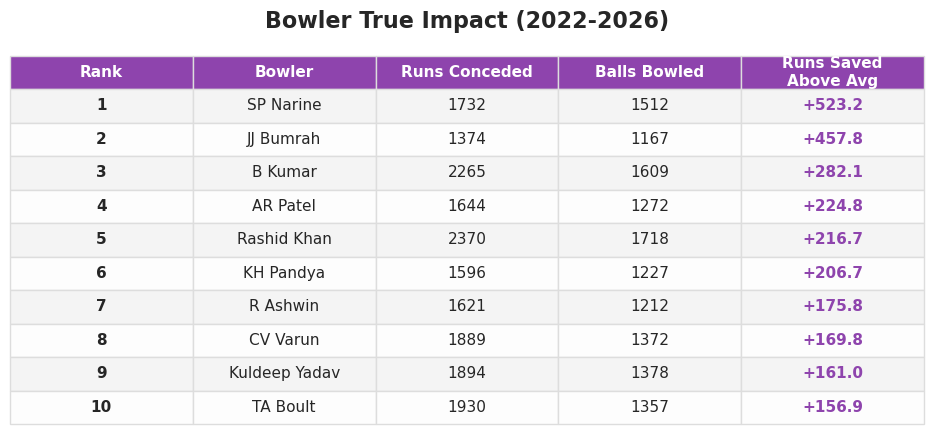

In [32]:
# --- STEP 1: Filter for the Modern Era & Standard Matches ---
target_seasons = ['2022', '2023', '2024', '2025', '2026', 2022, 2023, 2024, 2025, 2026]

# ---> THE FIX: Added is_rain_reduced == 0 <---
modern_df = df[(df['season'].isin(target_seasons)) & (df['is_rain_reduced'] == 0)].copy()

# --- STEP 2: Define Bowler Runs and Legal Balls ---
modern_df['bowler_runs'] = modern_df['runs_batter'] + modern_df['extras_wides'].fillna(0) + modern_df['extras_noballs'].fillna(0)
modern_df['is_legal_ball'] = np.where((modern_df['extras_wides'].fillna(0) == 0) & (modern_df['extras_noballs'].fillna(0) == 0), 1, 0)

# --- STEP 3: Calculate the League Environment (Baseline) ---
phase_env = modern_df.groupby('phase').agg(
    total_league_runs=('bowler_runs', 'sum'),
    total_league_balls=('is_legal_ball', 'sum') 
).reset_index()

phase_env['league_avg_rpb'] = phase_env['total_league_runs'] / phase_env['total_league_balls']

# --- STEP 4: Calculate Individual Bowler Stats per Phase ---
bowler_phase_stats = modern_df.groupby(['bowler', 'phase']).agg(
    actual_runs_conceded=('bowler_runs', 'sum'),
    legal_balls_bowled=('is_legal_ball', 'sum')
).reset_index()

impact_df = pd.merge(bowler_phase_stats, phase_env[['phase', 'league_avg_rpb']], on='phase', how='left')

# --- STEP 5: The True Impact Math ---
impact_df['expected_runs'] = impact_df['legal_balls_bowled'] * impact_df['league_avg_rpb']
impact_df['true_impact_rsaa'] = impact_df['expected_runs'] - impact_df['actual_runs_conceded']

# --- STEP 6: Aggregate the Final Leaderboard ---
final_impact = impact_df.groupby('bowler').agg(
    Total_Runs_Conceded=('actual_runs_conceded', 'sum'),
    Total_Legal_Balls=('legal_balls_bowled', 'sum'),
    True_Impact=('true_impact_rsaa', 'sum')
).reset_index()

# Filter for meaningful sample size (min 300 balls / 50 overs)
final_impact = final_impact[final_impact['Total_Legal_Balls'] >= 300]
top_impact_bowlers = final_impact.sort_values(by='True_Impact', ascending=False).head(10)

# Clean up formatting for the image
top_impact_bowlers['True_Impact'] = "+" + top_impact_bowlers['True_Impact'].round(1).astype(str)
top_impact_bowlers = top_impact_bowlers.rename(columns={
    'bowler': 'Bowler',
    'Total_Runs_Conceded': 'Runs Conceded',
    'Total_Legal_Balls': 'Balls Bowled',
    'True_Impact': 'Runs Saved\nAbove Avg'
}).reset_index(drop=True)

top_impact_bowlers.insert(0, 'Rank', range(1, 11))

# ==========================================
# --- STEP 7: FUNCTION TO DRAW THE IMAGE ---
# ==========================================
def render_impact_table(data, title, header_color, filename):
    # ---> THE FIX: Shrunk width from 12 to 8.5 <---
    fig, ax = plt.subplots(figsize=(9.5, 4.5)) 
    ax.axis('off')
    
    table = ax.table(
        cellText=data.values, 
        colLabels=data.columns, 
        cellLoc='center', 
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#dddddd')
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(weight='bold', color='white', fontsize=11)
        else:
            cell.set_facecolor('#fdfdfd' if row % 2 == 0 else '#f4f4f4')
            if col == 0: 
                cell.set_text_props(weight='bold')
            if col == 4: # Highlight the RSAA column
                cell.set_text_props(weight='bold', color='#8e44ad') # Deep purple
                
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Save the visual using our custom tool before showing
    save_report_visual(fig, filename)
    plt.show()

# --- STEP 8: GENERATE THE IMAGE ---
render_impact_table(
    top_impact_bowlers[['Rank', 'Bowler', 'Runs Conceded', 'Balls Bowled', 'Runs Saved\nAbove Avg']], 
    "Bowler True Impact (2022-2026)", 
    '#8e44ad',
    'true_impact_bowlers_leaderboard.png'
)

# The IPL Score Inflation

Saved: increased_median_score_impact_trend.png


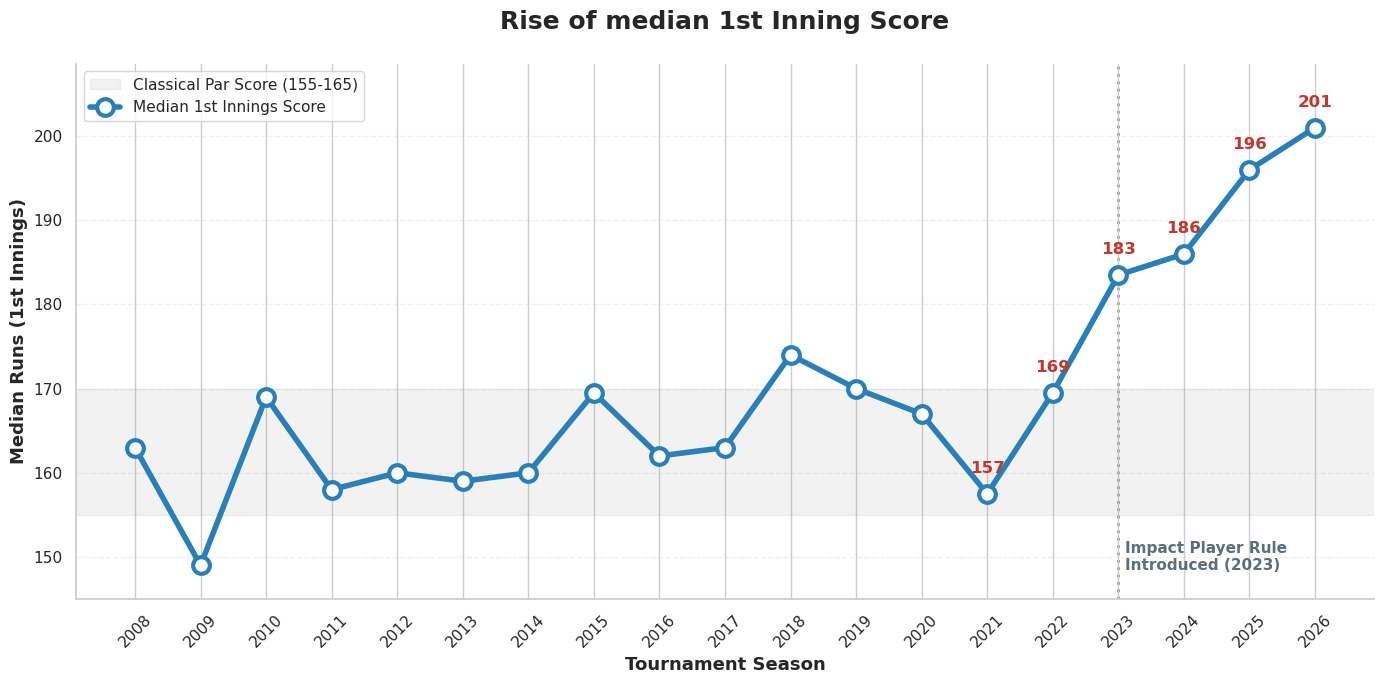

In [40]:
# --- STEP 1: Filter and Calculate Median Scores ---
valid_df = df.copy()

# Get total scores for the 1st innings per match
inn1_scores = valid_df[(valid_df['innings'] == 1) & (valid_df['is_rain_reduced'] == 0)].groupby(['season', 'match_id'])['runs_total'].sum().reset_index()

# Find the median score per season
inflation_trend = inn1_scores.groupby('season')['runs_total'].median().reset_index()
inflation_trend['season'] = inflation_trend['season'].astype(int)

# --- STEP 2: Build the High-Clarity Visual ---
fig, ax = plt.subplots(figsize=(14, 7))

# 1. Add a "Classical Era" Background Shading (The 155-165 Run Zone)
ax.axhspan(155, 170, color='gray', alpha=0.1, label='Classical Par Score (155-165)')

# 2. Add the Impact Player Annotation (Placed low to avoid data obstruction)
ax.axvline(x=2023, color='#34495e', linestyle=':', linewidth=2, alpha=0.6, zorder=0)
ax.text(
    2023.1, # Shifted slightly right of the line
    150,    # Placed safely below the data points and the grey shaded zone
    'Impact Player Rule\nIntroduced (2023)', 
    color='#34495e', 
    fontsize=11, 
    fontweight='bold', 
    alpha=0.8,
    va='center'
)

# 3. Draw the Main Trend Line (Swapped to a professional deep blue)
line_color = '#2980b9'

ax.plot(
    inflation_trend['season'], 
    inflation_trend['runs_total'], 
    color=line_color, 
    linewidth=4, 
    marker='o', 
    markersize=12, 
    mfc='white', 
    mew=3,       
    label='Median 1st Innings Score',
    zorder=3
)

# 4. Add Data Labels for the "Inflation Era" (2022-2025)
for i, row in inflation_trend.iterrows():
    if row['season'] >= 2021:
        ax.text(
            row['season'], 
            row['runs_total'] + 2.5, 
            f"{int(row['runs_total'])}", 
            ha='center', 
            fontsize=12, 
            fontweight='bold', 
            color='#c0392b'
        )

# --- STEP 3: Professional Formatting ---
# Perfect X-Axis (Whole years only)
all_seasons = inflation_trend['season'].unique()
ax.set_xticks(all_seasons)
ax.set_xticklabels(all_seasons, rotation=45, fontsize=11)

# Dynamic Y-Axis so the bottom annotation doesn't get cut off
current_ylim = ax.get_ylim()
ax.set_ylim(145, current_ylim[1] + 5)

# Upgraded Narrative Title
plt.title('Rise of median 1st Inning Score', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Median Runs (1st Innings)', fontsize=13, fontweight='bold')

# Subtle Grid and Aesthetic clean-up
plt.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(loc='upper left', frameon=True)
sns.despine()

plt.tight_layout()

# --- STEP 4: Export and Display ---
save_report_visual(fig, 'increased_median_score_impact_trend.png')
plt.show()

Saved: 200_plus_probability_trend.png


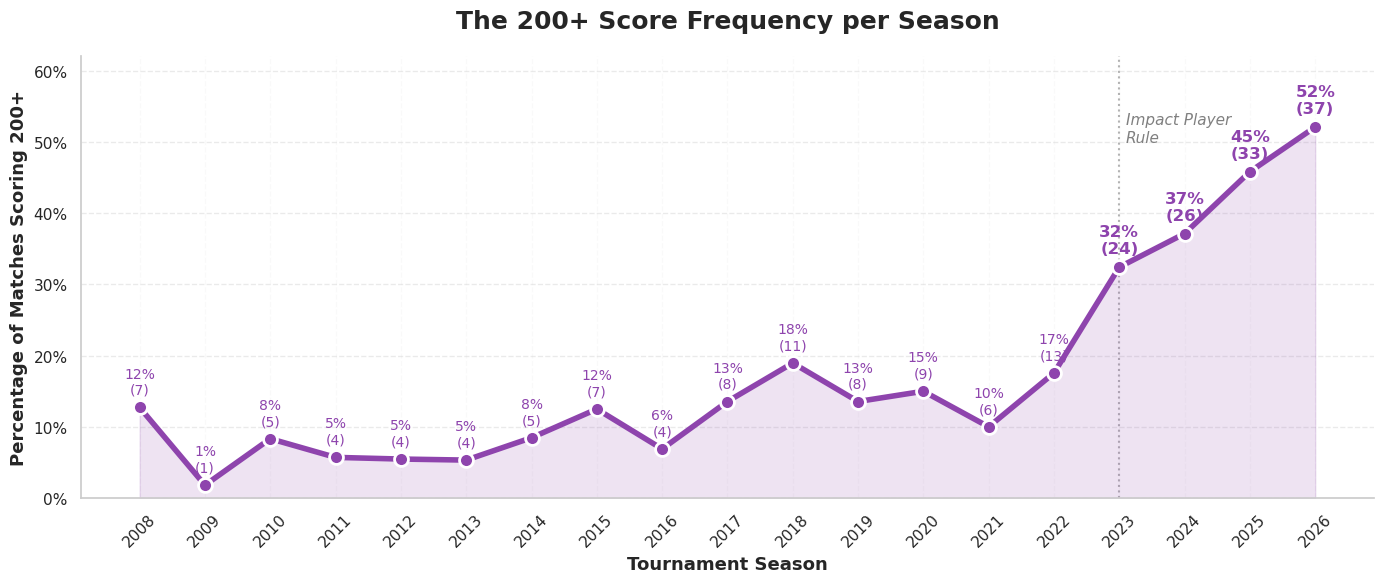

In [ ]:
# --- STEP 1: Filter Data & Calculate 1st Innings Scores ---
valid_df = df.copy()

# Get total scores for the 1st innings per match
inn1_scores = valid_df[(valid_df['innings'] == 1) & (valid_df['is_rain_reduced']==0)].groupby(['season', 'match_id'])['runs_total'].sum().reset_index()

# --- STEP 2: Flag and Calculate the RATE of 200+ Scores ---
inn1_scores['is_200_plus'] = (inn1_scores['runs_total'] >= 200).astype(int)

# THE FIX: Calculate the mean to get the true percentage rate, immune to schedule expansion
monster_scores = inn1_scores.groupby('season').agg(
    count_200_plus=('is_200_plus', 'sum'),
    rate_200_plus=('is_200_plus', 'mean')
).reset_index()

monster_scores['rate_200_plus'] = monster_scores['rate_200_plus'] * 100
monster_scores['season'] = monster_scores['season'].astype(int)

# --- STEP 3: Build the Bulletproof Visual ---
fig, ax = plt.subplots(figsize=(14, 6))

line_color = '#8e44ad' 

# Draw the line using the RATE, not the raw count
sns.lineplot(
    data=monster_scores, 
    x='season', 
    y='rate_200_plus', # Swapped to our true probability metric
    color=line_color, 
    linewidth=4, 
    marker='o', 
    markersize=10,
    markeredgecolor='white',
    markeredgewidth=2,
    zorder=3,
    ax=ax
)

# Add the premium semi-transparent fill
ax.fill_between(
    monster_scores['season'], 
    monster_scores['rate_200_plus'], 
    color=line_color, 
    alpha=0.15,
    zorder=2
)

# --- STEP 4: Narrative Annotations ---
for i, row in monster_scores.iterrows():
    # Bold the text for the crazy high modern percentages
    font_w = 'bold' if row['rate_200_plus'] > 20 else 'normal'
    font_s = 12 if row['rate_200_plus'] > 20 else 10
    
    # We display the percentage, but also keep the raw count in brackets for context!
    ax.text(
        row['season'], 
        row['rate_200_plus'] + 1.5, 
        f"{int(row['rate_200_plus'])}%\n({int(row['count_200_plus'])})", 
        ha='center', 
        va='bottom',
        color=line_color, 
        fontweight=font_w, 
        fontsize=font_s
    )

# Add the Impact Player milestone for context
ax.axvline(2023, color='gray', linestyle=':', alpha=0.6, zorder=0)

# Nudged up to 88% of the chart height, anchored at the top
ax.text(
    2023.1, 
    ax.get_ylim()[1] * 0.99, 
    'Impact Player\nRule', 
    color='gray', 
    fontsize=11, 
    style='italic',
    va='top' 
)


# --- STEP 5: Perfect Formatting ---
all_seasons = monster_scores['season'].unique()
ax.set_xticks(all_seasons)
ax.set_xticklabels(all_seasons, rotation=45, fontsize=11) 

# Ensure the Y-axis has enough headroom and format it as percentages
ax.set_ylim(0, monster_scores['rate_200_plus'].max() + 10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Formatting and Labels
plt.title('The 200+ Score Frequency per Season', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Percentage of Matches Scoring 200+', fontsize=13, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.grid(axis='x', linestyle='--', alpha=0.1) 

sns.despine()
plt.tight_layout()

# --- STEP 6: Export and Display ---
save_report_visual(fig, '200_plus_probability_trend.png')
plt.show()

Saved: boundary_hitting_per_match.png


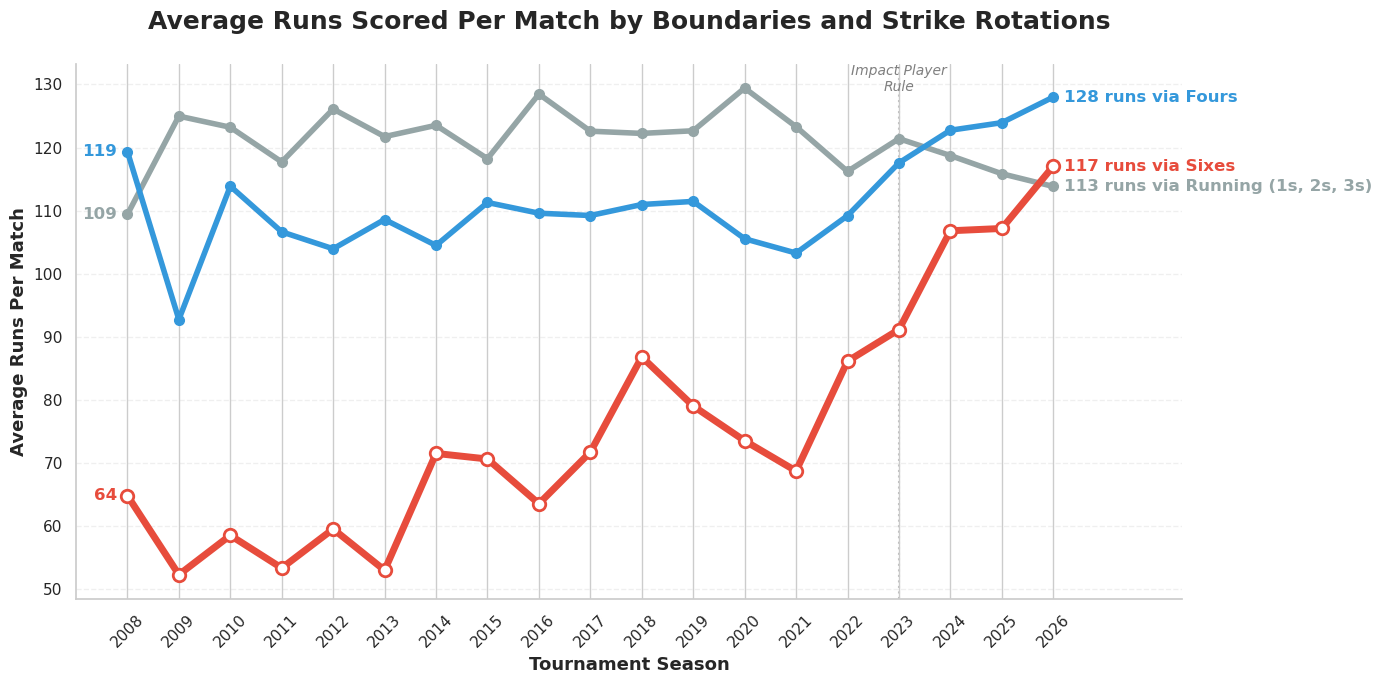

In [42]:
# --- STEP 1: Filter Data & Calculate Run Types ---
valid_df = df[(df['is_rain_reduced'] == 0)].copy()

# Calculate raw runs specifically from 4s, 6s, and totals
fours_df = valid_df[valid_df['runs_batter'] == 4].groupby('season')['runs_batter'].sum().reset_index(name='runs_from_4s')
sixes_df = valid_df[valid_df['runs_batter'] == 6].groupby('season')['runs_batter'].sum().reset_index(name='runs_from_6s')
season_totals = valid_df.groupby('season')['runs_batter'].sum().reset_index(name='total_runs')

# Count matches to normalize
match_counts = valid_df.groupby('season')['match_id'].nunique().reset_index(name='total_matches')

# Merge and calculate running
avg_df = season_totals.merge(fours_df, on='season').merge(sixes_df, on='season').merge(match_counts, on='season')
avg_df['runs_running'] = avg_df['total_runs'] - avg_df['runs_from_4s'] - avg_df['runs_from_6s']

# --- STEP 2: Normalize to "Runs Per Match" ---
avg_df['running_per_match'] = avg_df['runs_running'] / avg_df['total_matches']
avg_df['fours_per_match'] = avg_df['runs_from_4s'] / avg_df['total_matches']
avg_df['sixes_per_match'] = avg_df['runs_from_6s'] / avg_df['total_matches']
avg_df['season'] = avg_df['season'].astype(int)

# --- STEP 3: Build the Minimalist Visual ---
fig, ax = plt.subplots(figsize=(14, 7))

color_run = '#95a5a6' # Subdued grey
color_4s = '#3498db'  # Solid Blue
color_6s = '#e74c3c'  # Aggressive Red

# Plot the clean lines
ax.plot(avg_df['season'], avg_df['running_per_match'], color=color_run, linewidth=4, marker='o', markersize=7, label='Running')
ax.plot(avg_df['season'], avg_df['fours_per_match'], color=color_4s, linewidth=4, marker='o', markersize=7, label='Fours')
ax.plot(avg_df['season'], avg_df['sixes_per_match'], color=color_6s, linewidth=5, marker='o', markersize=9, mfc='white', mew=2, label='Sixes')

# --- STEP 4: Direct Labeling (Zero Clutter) ---
# We only annotate the very first year (2008) and the very last year to show the shift
first_year = avg_df['season'].min()
last_year = avg_df['season'].max()

lines_to_label = [
    ('running_per_match', color_run, 'Running (1s, 2s, 3s)'),
    ('fours_per_match', color_4s, 'Fours'),
    ('sixes_per_match', color_6s, 'Sixes')
]

for col, color, label_text in lines_to_label:
    first_val = avg_df[avg_df['season'] == first_year][col].values[0]
    last_val = avg_df[avg_df['season'] == last_year][col].values[0]
    
    # Label the starting value on the left
    ax.text(first_year - 0.2, first_val, f"{int(first_val)}", color=color, ha='right', va='center', fontweight='bold', fontsize=12)
    
    # Label the ending value AND the category name on the right (Replaces the Legend!)
    ax.text(last_year + 0.2, last_val, f"{int(last_val)} runs via {label_text}", color=color, ha='left', va='center', fontweight='bold', fontsize=12)

# Add a subtle vertical line to mark the Impact Player era
ax.axvline(2023, color='gray', linestyle=':', alpha=0.5, zorder=0)
ax.text(2023, ax.get_ylim()[1], 'Impact Player\nRule', color='gray', ha='center', va='top', fontsize=10, style='italic')

# --- STEP 5: Professional Formatting ---
ax.set_xticks(avg_df['season'].unique())
ax.set_xticklabels(avg_df['season'].unique(), rotation=45, fontsize=11)

# Expand X-axis limits slightly to fit our new side-labels perfectly
ax.set_xlim(first_year - 1, last_year + 2.5)

plt.title('Average Runs Scored Per Match by Boundaries and Strike Rotations', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Tournament Season', fontsize=13, fontweight='bold')
plt.ylabel('Average Runs Per Match', fontsize=13, fontweight='bold')

# Turn off the legend, right border, and top border for maximum cleanliness
sns.despine()
ax.legend_.remove() if ax.get_legend() else None
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

# --- STEP 6: Export and Display ---
save_report_visual(fig, 'boundary_hitting_per_match.png')
plt.show()